In [70]:
# import libraries 

# data
import pandas as pd
import numpy as np

# visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# processing and splitting
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

# handling class imbalance
# install imblearn onto notebook
#!pip install imblearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ml models
from sklearn.linear_model import LogisticRegression

# install xgboost onto notebook
# !pip install xgboost
import xgboost as xgb

# model evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# model interpretation (optional)
# install shap onto notebook
# !pip install shap
import shap

# utility
import warnings
warnings.filterwarnings('ignore')

In [55]:
# load data

import os
DATA_PATH = os.environ.get("CREDITCARD_CSV", "creditcard.csv")
df = pd.read_csv(DATA_PATH)

# basic info to explore the data
# print(df.info())
# print(df.describe())
# print(df['Class'].value_counts())


# data processing

# 1. check for missing vals
# print(df.isnull().sum()) # no missing vals, G

# print (df.columns)

# 2. Extract Hour feature from the original Time column (before any scaling)
#    Time is in seconds from the first transaction; convert to hour-of-day (0-23)
df['Hour'] = (df['Time'] // 3600) % 24

# Drop original Time and Amount columns (will be scaled below)
df = df.drop(['Time', 'Amount'], axis=1)

# print (df.columns)


In [56]:
# train test split

# separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale 'Hour' with RobustScaler — fit ONLY on training data to prevent data leakage
robust_scaler = RobustScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Hour'] = robust_scaler.fit_transform(X_train[['Hour']])
X_test['Hour'] = robust_scaler.transform(X_test[['Hour']])

# handle class imbalance with SMOTE
# fraud cases are rare, so we create synthetic minority samples
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Original training set class distribution:")
print(y_train.value_counts())
print("\nResampled training set class distribution:")
print(y_train_res.value_counts())


Original training set class distribution:
0    227451
1       394
Name: Class, dtype: int64

Resampled training set class distribution:
0    227451
1    227451
Name: Class, dtype: int64



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.86      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9791767755216886


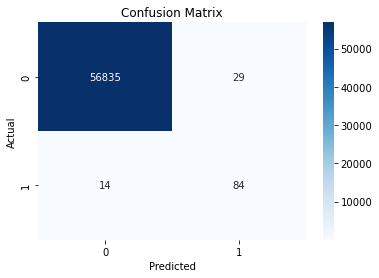

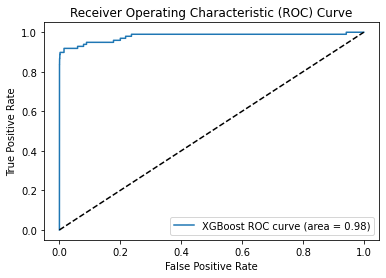

In [69]:
# model selection

# logistic regression
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, roc_auc_score

# model = LogisticRegression(class_weight='balanced', max_iter=1000)
# model.fit(X_train_res, y_train_res)

# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

# XGBoost
# train XGBoost classifier
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_res, y_train_res)

# evaluate model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='XGBoost ROC curve (area = %.2f)' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [75]:
# hyperparameter Tuning with Optuna
!pip install optuna
import optuna
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# -----------------------------
# Define Objective Function
# -----------------------------
def objective(trial):
    # Define hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0)
    }
    
    # Train XGBoost with given parameters
    model = XGBClassifier(
        **params,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_res, y_train_res)
    
    # Predict probabilities on validation set
    y_proba = model.predict_proba(X_test)[:,1]
    
    # Return ROC-AUC score for Optuna to maximize
    return roc_auc_score(y_test, y_proba)

# -----------------------------
# Run the Study
# -----------------------------
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # Try 30 parameter sets (much faster than RandomizedSearchCV)

# Best parameters and score
print("Best Parameters:", study.best_params)
print("Best ROC-AUC Score:", study.best_value)

# -----------------------------
# Train Final Model with Best Parameters
# -----------------------------
best_params = study.best_params
best_model = XGBClassifier(**best_params, eval_metric='logloss', random_state=42)
best_model.fit(X_train_res, y_train_res)

#output: 
# Best Parameters: {'n_estimators': 418, 'max_depth': 8, 'learning_rate': 0.059031600581882615, 'subsample': 0.6828136850560313, 'colsample_bytree': 0.5019738393041108, 'gamma': 0.339901603520564, 'reg_alpha': 0.28484871827142955, 'reg_lambda': 0.659919592166845}
# Best ROC-AUC Score: 0.9823752411769435



     |████████████████████████████████| 400 kB 3.8 MB/s eta 0:00:01
     |████████████████████████████████| 247 kB 25.8 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 10.0 MB/s eta 0:00:01
     |████████████████████████████████| 44 kB 4.5 MB/s  eta 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.9.0
    Uninstalling typing-extensions-4.9.0:
      Successfully uninstalled typing-extensions-4.9.0


[I 2025-09-23 16:27:53,921] A new study created in memory with name: no-name-cc4bb724-6d39-46ba-80f3-d1fc5281f2be
[I 2025-09-23 16:27:58,474] Trial 0 finished with value: 0.9795414120910041 and parameters: {'n_estimators': 285, 'max_depth': 6, 'learning_rate': 0.29756530167276113, 'subsample': 0.9136596833570672, 'colsample_bytree': 0.5485051804206145, 'gamma': 0.21118086327088942, 'reg_alpha': 0.9207784144451612, 'reg_lambda': 1.2796473718486823}. Best is trial 0 with value: 0.9795414120910041.
[I 2025-09-23 16:28:11,313] Trial 1 finished with value: 0.9748887068896213 and parameters: {'n_estimators': 445, 'max_depth': 7, 'learning_rate': 0.011681208336339951, 'subsample': 0.6333226190955263, 'colsample_bytree': 0.8253432687974311, 'gamma': 0.11613312864066799, 'reg_alpha': 0.25865593622029937, 'reg_lambda': 0.8035968797967257}. Best is trial 0 with value: 0.9795414120910041.
[I 2025-09-23 16:28:18,490] Trial 2 finished with value: 0.9819246494320858 and parameters: {'n_estimators': 3

Best Parameters: {'n_estimators': 418, 'max_depth': 8, 'learning_rate': 0.059031600581882615, 'subsample': 0.6828136850560313, 'colsample_bytree': 0.5019738393041108, 'gamma': 0.339901603520564, 'reg_alpha': 0.28484871827142955, 'reg_lambda': 0.659919592166845}
Best ROC-AUC Score: 0.9823752411769435


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5019738393041108, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=0.339901603520564, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.059031600581882615,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=418, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

Classification Report (Optuna Tuned Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9823752411769435


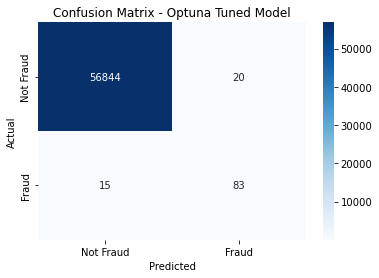

In [76]:
# evaluate on test set
# Predictions
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:,1]

# Metrics
print("Classification Report (Optuna Tuned Model):")
print(classification_report(y_test, y_pred_best))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Optuna Tuned Model')
plt.show()


Classification Report (Final Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score (Final Model): 0.9823752411769435


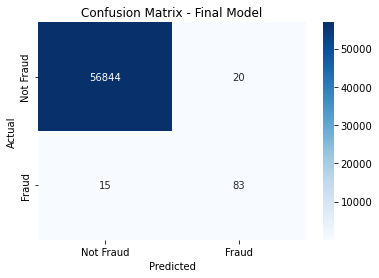

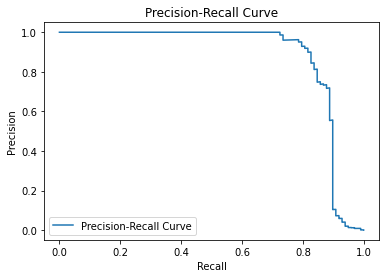

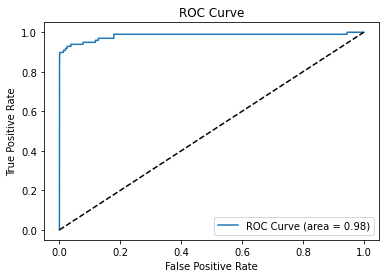

In [77]:
# Train final XGBoost model with best parameters
best_params = {
    'n_estimators': 418,
    'max_depth': 8,
    'learning_rate': 0.059031600581882615,
    'subsample': 0.6828136850560313,
    'colsample_bytree': 0.5019738393041108,
    'gamma': 0.339901603520564,
    'reg_alpha': 0.28484871827142955,
    'reg_lambda': 0.659919592166845
}

final_model = XGBClassifier(**best_params, eval_metric='logloss', random_state=42)
final_model.fit(X_train_res, y_train_res)

# Predictions on test data
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:,1]

# Metrics
print("Classification Report (Final Model):")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC Score (Final Model):", roc_auc_score(y_test, y_proba_final))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Model')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_final)
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
plt.plot(fpr, tpr, label="ROC Curve (area = %.2f)" % roc_auc_score(y_test, y_proba_final))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

